In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix
from sklearn import metrics,model_selection
from sklearn.preprocessing import scale
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import warnings

In [2]:
df = pd.read_excel("Election_Data.Xlsx", sheet_name="Election_Dataset_Two Classes")

In [3]:
df.head(5)

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,1,Labour,43,3,3,4,1,2,2,female
1,2,Labour,36,4,4,4,4,5,2,male
2,3,Labour,35,4,4,5,2,3,2,male
3,4,Labour,24,4,2,2,1,4,0,female
4,5,Labour,41,2,2,1,1,6,2,male


In [4]:
df.tail(5)

,Unnamed: 0,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
1520,1521,Conservative,67,5,3,2,4,11,3,male
1521,1522,Conservative,73,2,2,4,4,8,2,male
1522,1523,Labour,37,3,3,5,4,2,2,male
1523,1524,Conservative,61,3,3,1,4,11,2,male
1524,1525,Conservative,74,2,3,2,4,11,0,female


In [5]:
#shape of the data
df.shape

(1525, 10)

The data set has 1525 rows and 10 columns

In [6]:
#checking the variables and their data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1525 entries, 0 to 1524
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               1525 non-null   int64 
 1   vote                     1525 non-null   object
 2   age                      1525 non-null   int64 
 3   economic.cond.national   1525 non-null   int64 
 4   economic.cond.household  1525 non-null   int64 
 5   Blair                    1525 non-null   int64 
 6   Hague                    1525 non-null   int64 
 7   Europe                   1525 non-null   int64 
 8   political.knowledge      1525 non-null   int64 
 9   gender                   1525 non-null   object
dtypes: int64(8), object(2)
memory usage: 119.3+ KB


Here it can be seen that all the variables except vote and gender have integer type as their data types.

Here another variable called as Unamed 0 is present which is not making sense in this data types so we will remove this. 

Vote is the target variable here which has 2 cateogries as defined in the data which are as follows: Conservative and Labour.

In [7]:
# removing the column
df.drop(columns='Unnamed: 0', inplace= True)

In [8]:
df.head(3)

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,Labour,43,3,3,4,1,2,2,female
1,Labour,36,4,4,4,4,5,2,male
2,Labour,35,4,4,5,2,3,2,male


In [9]:
#checking the null values
df.isnull().sum()

vote                       0
age                        0
economic.cond.national     0
economic.cond.household    0
Blair                      0
Hague                      0
Europe                     0
political.knowledge        0
gender                     0
dtype: int64

It can be clearly depicted that there are no null values present in the above data set.

In [10]:
#checking for any duplicates
df.duplicated().sum()

8

Total number of duplicated values is 8, so we will be removing these duplicates as duplicated values doesnot make any sense.

In [11]:
#removing the duplicated values
df.drop_duplicates(inplace= True)

In [12]:
df.shape

(1517, 9)

In [13]:
#checking the overall descriptive stats of the data
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
vote,1517,2,Labour,1057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1517.0,NaN,NaN,NaN,54.241266,15.701741,24.0,41.0,53.0,67.0,93.0
economic.cond.national,1517.0,NaN,NaN,NaN,3.245221,0.881792,1.0,3.0,3.0,4.0,5.0
economic.cond.household,1517.0,NaN,NaN,NaN,3.137772,0.931069,1.0,3.0,3.0,4.0,5.0
Blair,1517.0,NaN,NaN,NaN,3.335531,1.174772,1.0,2.0,4.0,4.0,5.0
Hague,1517.0,NaN,NaN,NaN,2.749506,1.232479,1.0,2.0,2.0,4.0,5.0
Europe,1517.0,NaN,NaN,NaN,6.740277,3.299043,1.0,4.0,6.0,10.0,11.0
political.knowledge,1517.0,NaN,NaN,NaN,1.540541,1.084417,0.0,0.0,2.0,2.0,3.0
gender,1517,2,female,808,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
for feature in df.columns:
    if df[feature].dtype=='object':
           print(feature.upper() ," ",df[feature].nunique())
           print(df[feature].value_counts().sort_values())
            

VOTE   2
Conservative     460
Labour          1057
Name: vote, dtype: int64
GENDER   2
male      709
female    808
Name: gender, dtype: int64


Here it can be seen that vote has 2 different subcateogries out of whoch Labour party has more number as compared to Conservative type.

No. of female voters are more as compared to male voters.

In [15]:
#Counting the value of vote counts
df["vote"].value_counts()

Labour          1057
Conservative     460
Name: vote, dtype: int64

In [16]:
##Counting the value of gender counts
df["gender"].value_counts()

female    808
male      709
Name: gender, dtype: int64

In [17]:
#replacing the values with 0 and 1 for gender and vote
replace = {
    "gender" : {"male" : 1 , "female" : 0},
    "vote"  :  { "Conservative" : 1, "Labour" : 0}
}

In [18]:
df = df.replace(replace)

In [19]:
#checking the skewness of the data set
df.skew()

vote                       0.857014
age                        0.139800
economic.cond.national    -0.238474
economic.cond.household   -0.144148
Blair                     -0.539514
Hague                      0.146191
Europe                    -0.141891
political.knowledge       -0.422928
gender                     0.130929
dtype: float64

Here it can be seen that age, vote and gender are positively skewed

Rest of them are negatively skeweed.

 # Univariate analysis

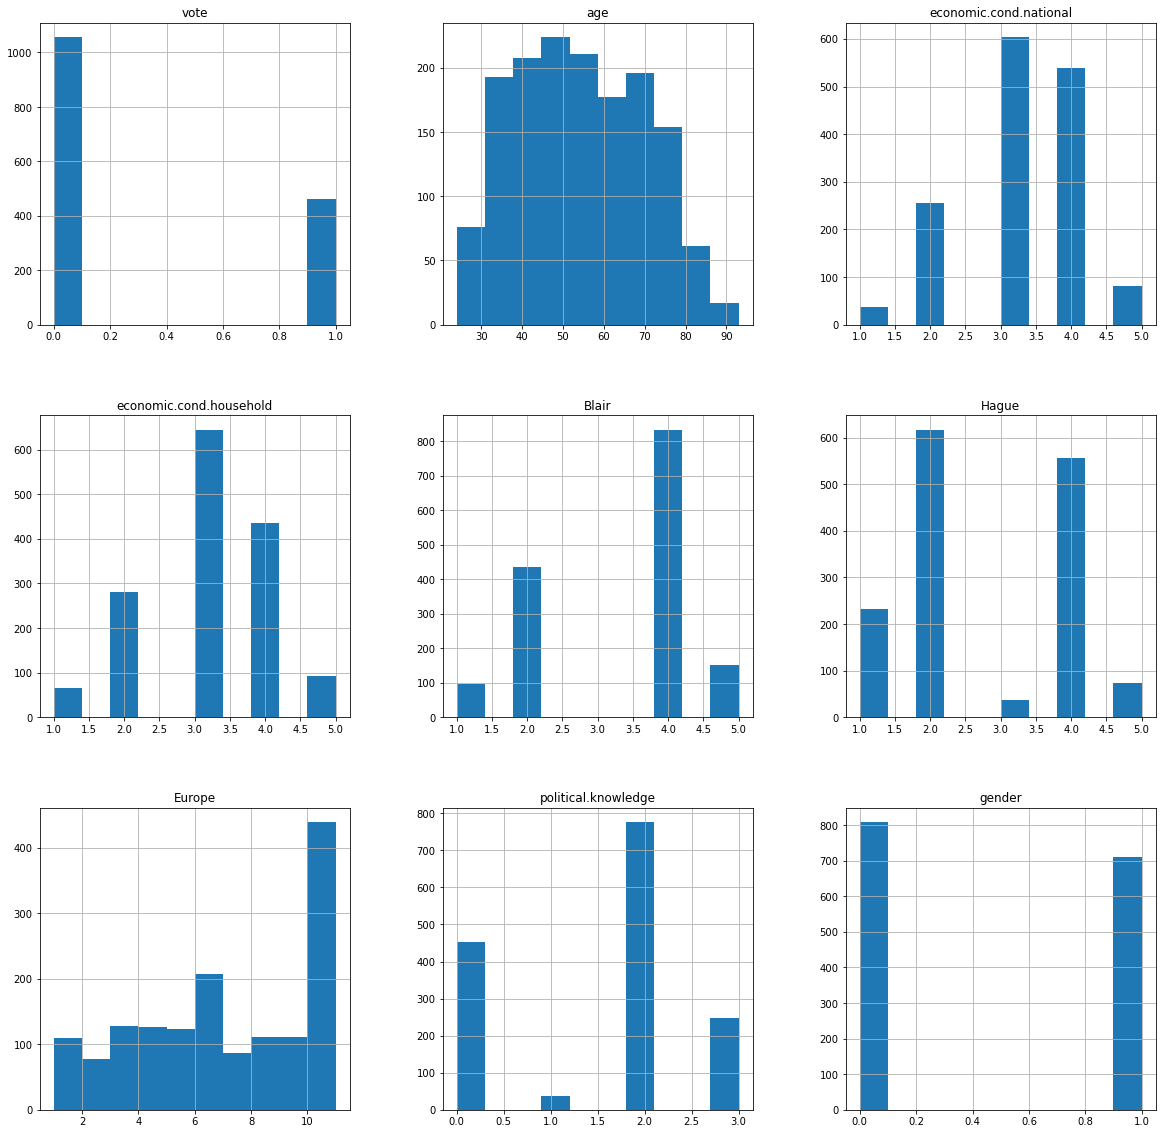

In [20]:
df.hist(figsize=(20,20))
plt.show()

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


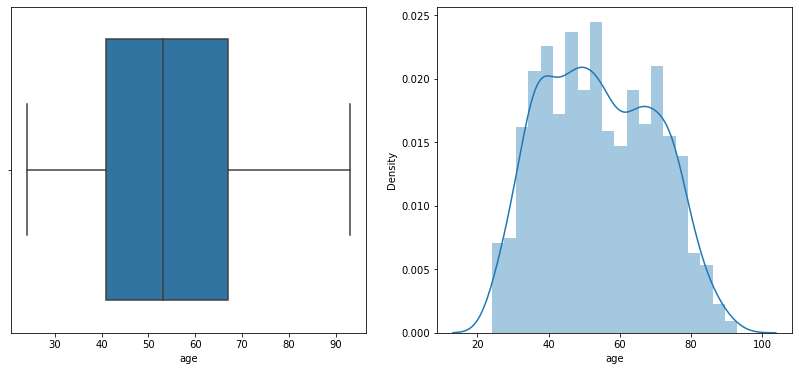

In [21]:
#distribution of age
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(df.age)
plt.subplot(1, 2, 2)
sns.distplot(df.age, bins = 20)
plt.show()

The box plot of the age column depicts no outliers values and thus seems to be normally distributed.

Here the data seems to be positively skeweed for the age column, which can be proved through several peak points present here.



C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


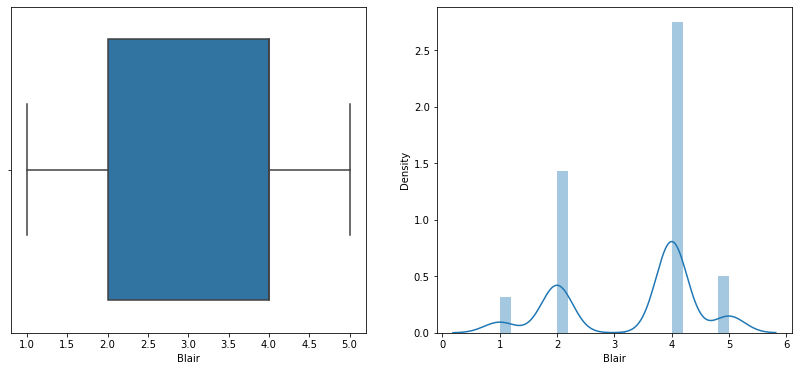

In [22]:
#distribution of Blair
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(df.Blair)
plt.subplot(1, 2, 2)
sns.distplot(df.Blair, bins = 20)
plt.show()

The box plot is normally distributed over here thus having no outliers values.

Here the distribution of data seems to be evenly skewed , as several high peak points can be seen in distribution.

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


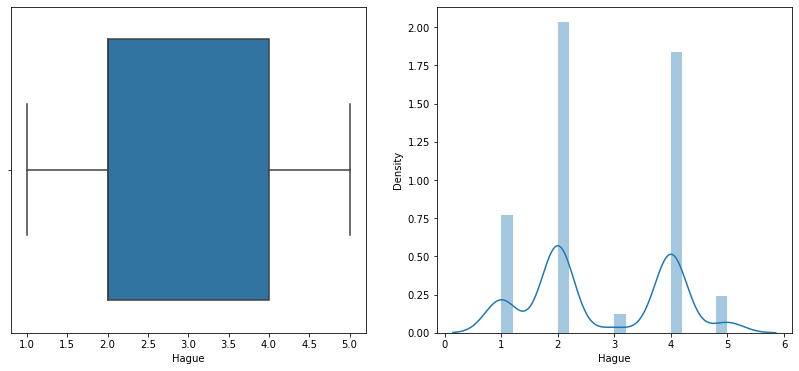

In [23]:
#distribution of Hague
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(df.Hague)
plt.subplot(1, 2, 2)
sns.distplot(df.Hague, bins = 20)
plt.show()

The box plot is normally distributed over here thus having no outliers values.

Here the distribution of data seems to be evenly skewed , as several high peak points can be seen in distribution.

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


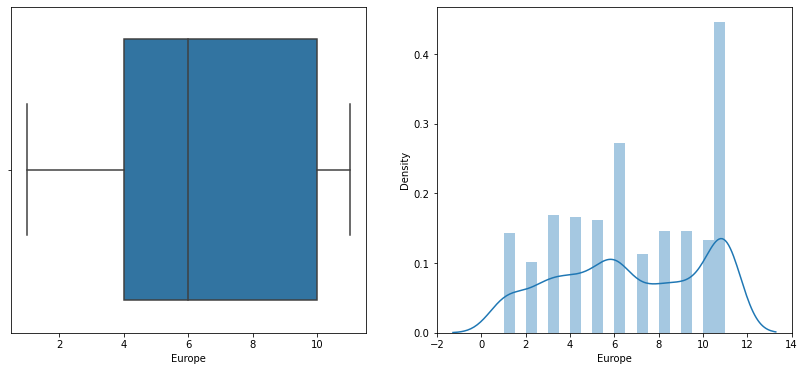

In [24]:
#distribution of Europe
plt.figure(figsize = (14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(df.Europe)
plt.subplot(1, 2, 2)
sns.distplot(df.Europe, bins = 20)
plt.show()

Here the box plot shows no outliers presence where as

Here the distribution of the data seems to be left skewed as only few  peak points can be seen in the distribution over here.

Age:  The distribution of the age seems not be normally distributed and is skewed.
    
    Mean is greater than median followed by mode.
    
    Majority of the people lies between the age group of 30 to 80yrs old.
    
    People belonging to high number of voters lies in the age group of 45 to 50 yrs old.
    
Blair:  Here variables are not normally distributed and are skeweed. Mode is greater than mean over here.
    
Hauge:  Here variables are not normally distributed and are skeweed. Mean  is greater than mode over here.
    
Europe: Here mode is higher than mean followed by median.

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\rahul\anacond

<AxesSubplot:xlabel='Hague', ylabel='age'>

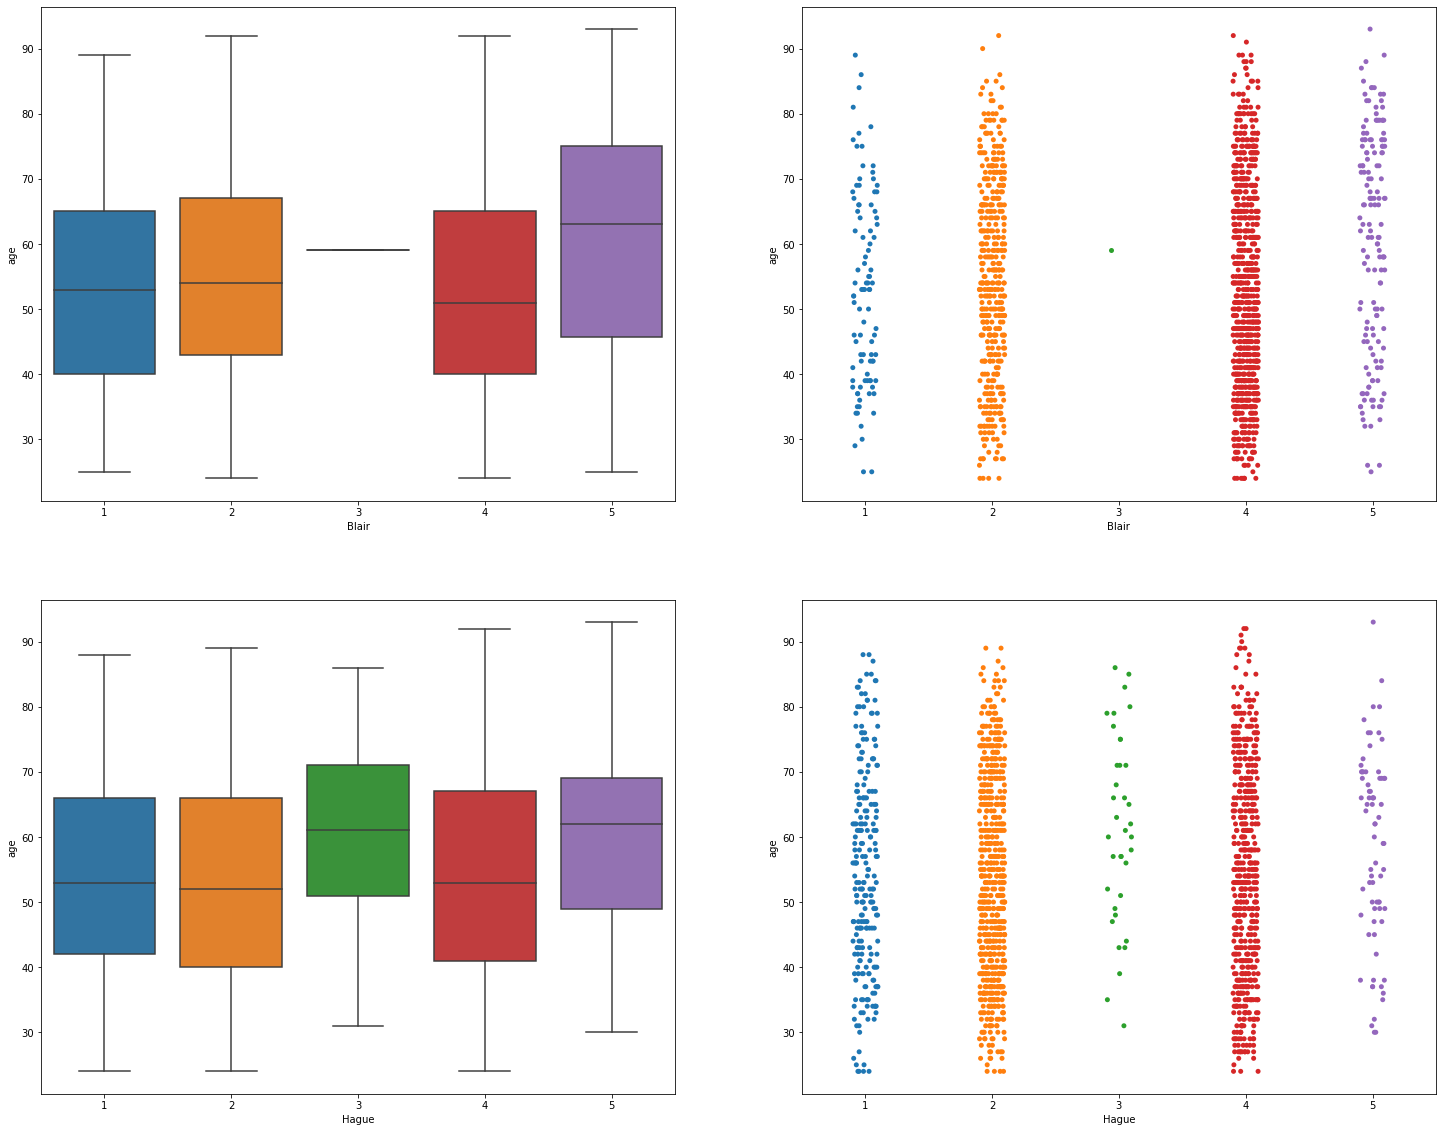

In [25]:
fig, axes = plt.subplots(nrows=2,ncols=2)
fig.set_size_inches(25,20)
sns.boxplot(df["Blair"],df["age"], ax = axes[0][0])
sns.stripplot(df["Blair"],df["age"], ax = axes[0][1])
sns.boxplot(df["Hague"],df["age"], ax = axes[1][0])
sns.stripplot(df["Hague"],df["age"], ax = axes[1][1])

# bivariate or multivariate analysis

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


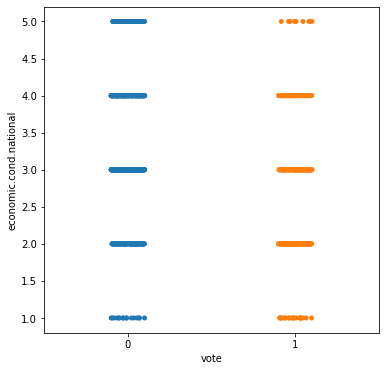

In [26]:
plt.figure(figsize=(6,6))
sns.stripplot(df["vote"], df['economic.cond.national'], jitter=True) 
plt.show()

From the above graph it can be clearly seen that labour and conservative the two of voting parties behave in similar way.

The economic cond national is not showing any effect on the two types of voting parties.

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


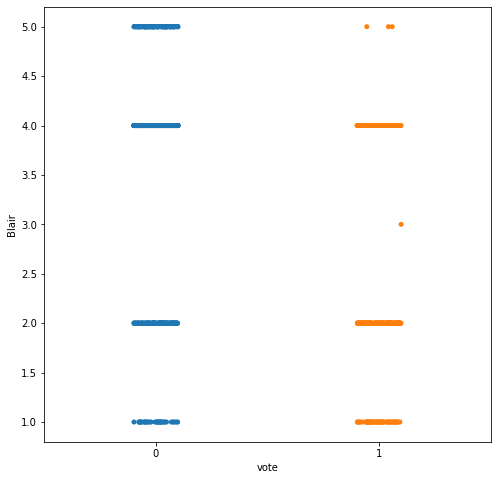

In [27]:
plt.figure(figsize=(8,8))
sns.stripplot(df["vote"], df['Blair'], jitter=True) 
plt.show()

From the above graph it can be clearly seen that labour and conservative the two of voting parties behave in similar way.

We can see that some values of conservation party is being present in blair .

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


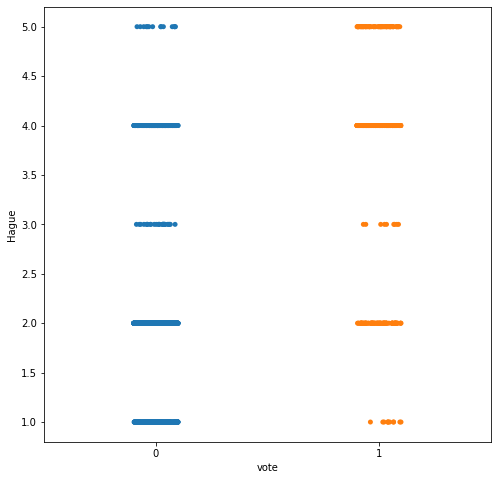

In [28]:
plt.figure(figsize=(8,8))
sns.stripplot(df["vote"], df['Hague'], jitter=True) 
plt.show()

From the above graph it can be clearly seen that labour and conservative the two of voting parties behave in similar way.

We can see that blair variable has no effect on two of voting parties type .

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


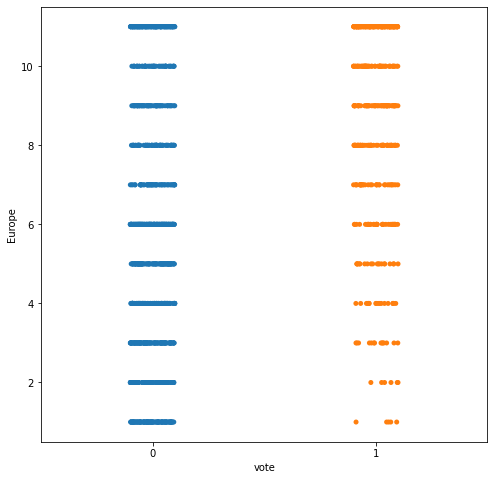

In [29]:
plt.figure(figsize=(8,8))
sns.stripplot(df["vote"], df['Europe'], jitter=True) 
plt.show()

From the above graph it can be clearly seen that labour and conservative the two of voting parties behave in similar way in europe.

We can see that conservative party presence is low as compared to labour party in europe .

C:\Users\rahul\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


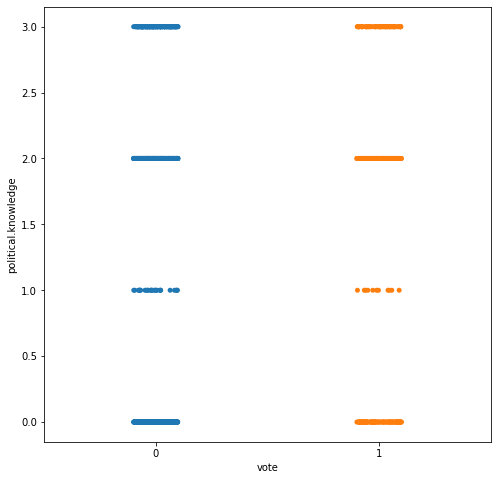

In [30]:
plt.figure(figsize=(8,8))
sns.stripplot(df["vote"], df['political.knowledge'], jitter=True) 
plt.show()

From the above graph it can be clearly seen that labour and conservative the two of voting parties behave in similar way in europe.

<AxesSubplot:xlabel='Hague', ylabel='Count'>

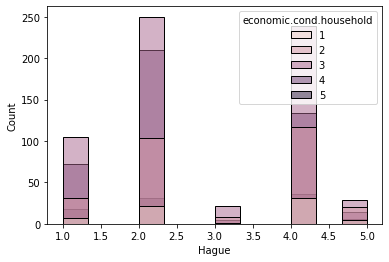

In [31]:
sns.histplot(data =df , x = "Hague", hue = "economic.cond.household")

<AxesSubplot:xlabel='Blair', ylabel='Count'>

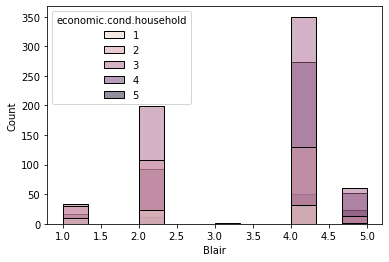

In [32]:
sns.histplot(data =df , x = "Blair", hue = "economic.cond.household")


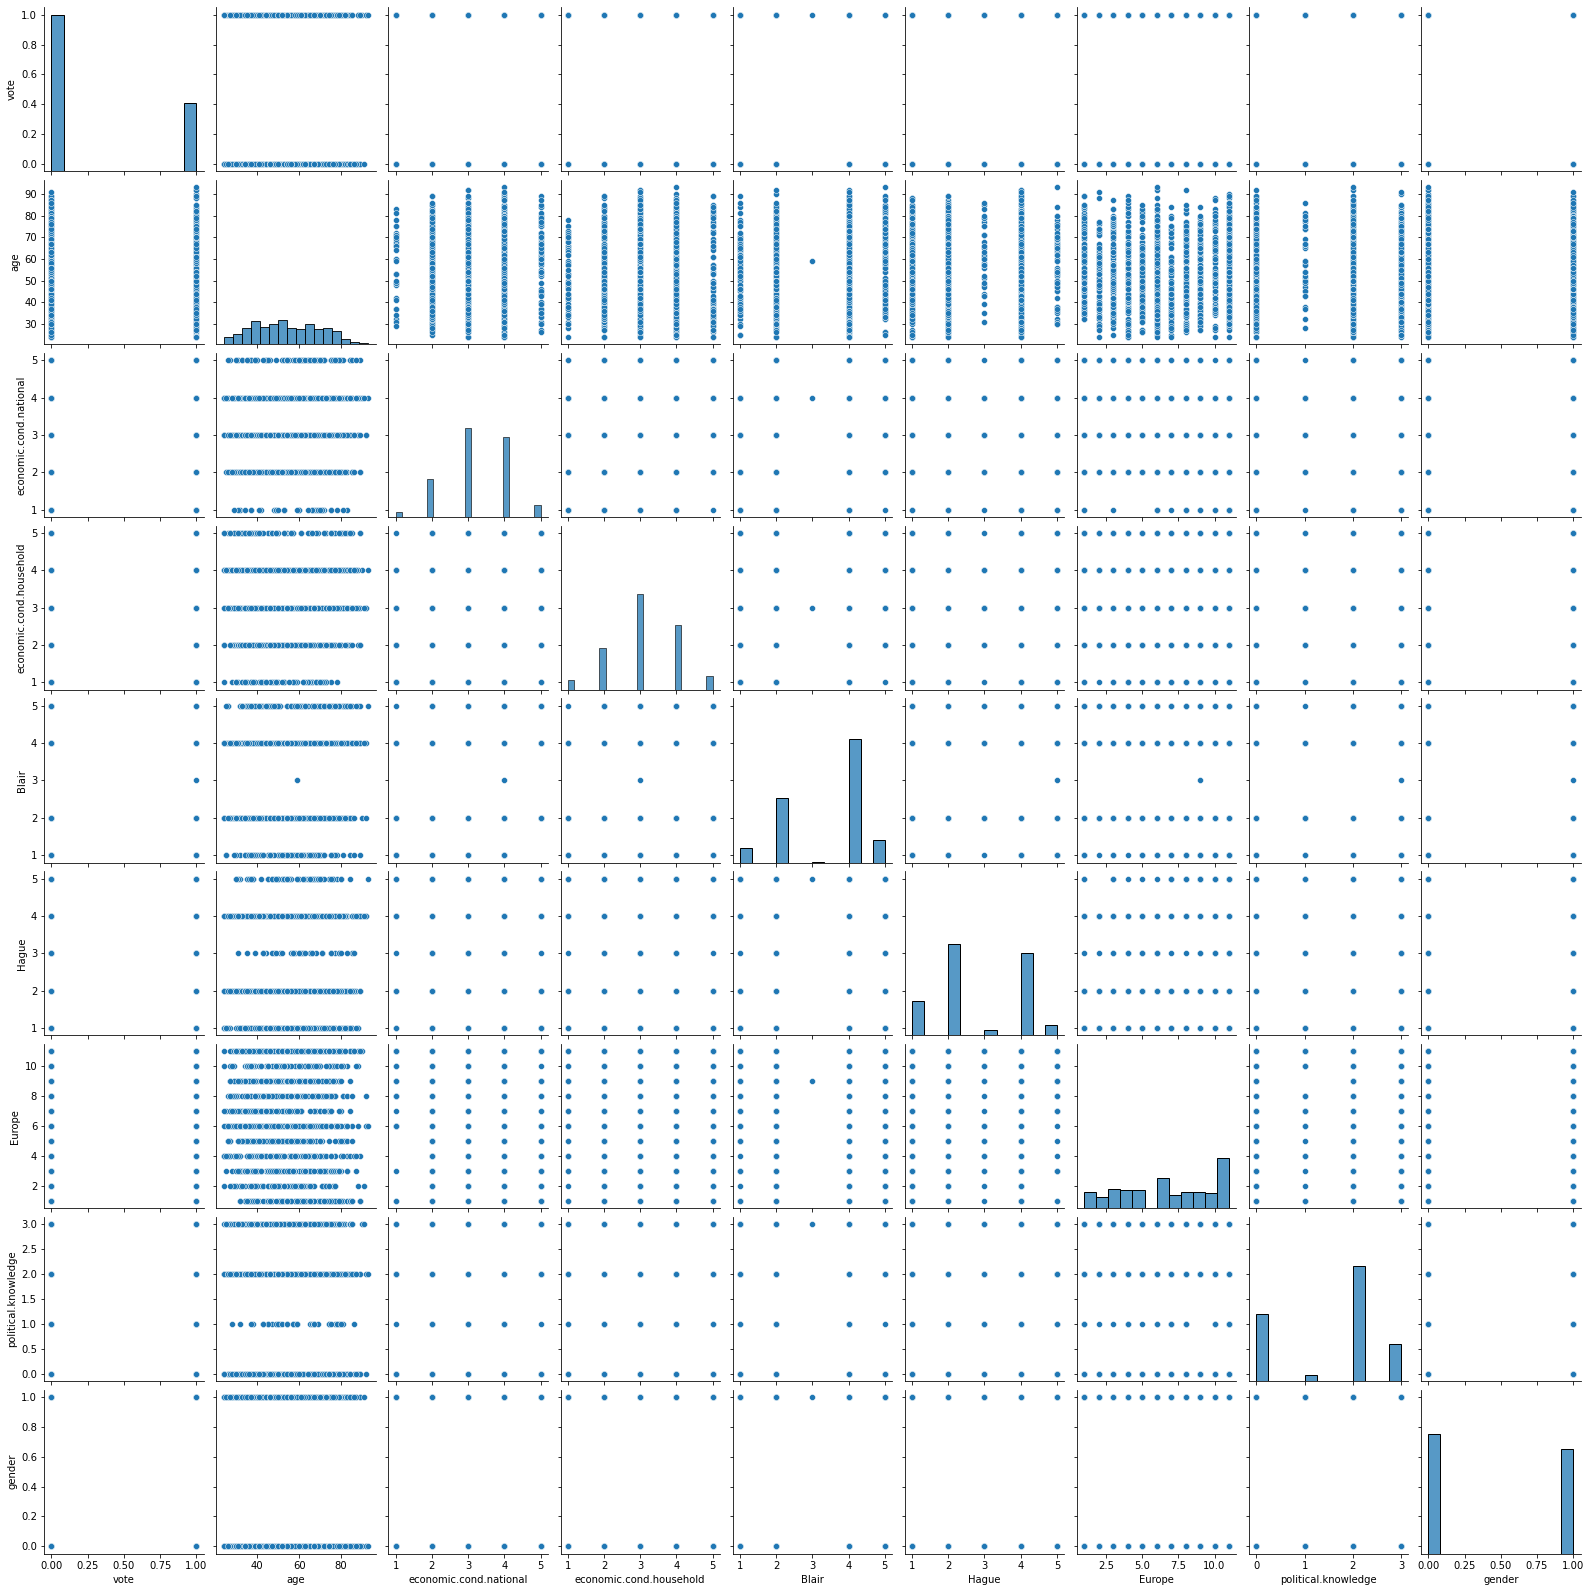

In [33]:
#checking the distribution of the data using pairplot
sns.pairplot(df)

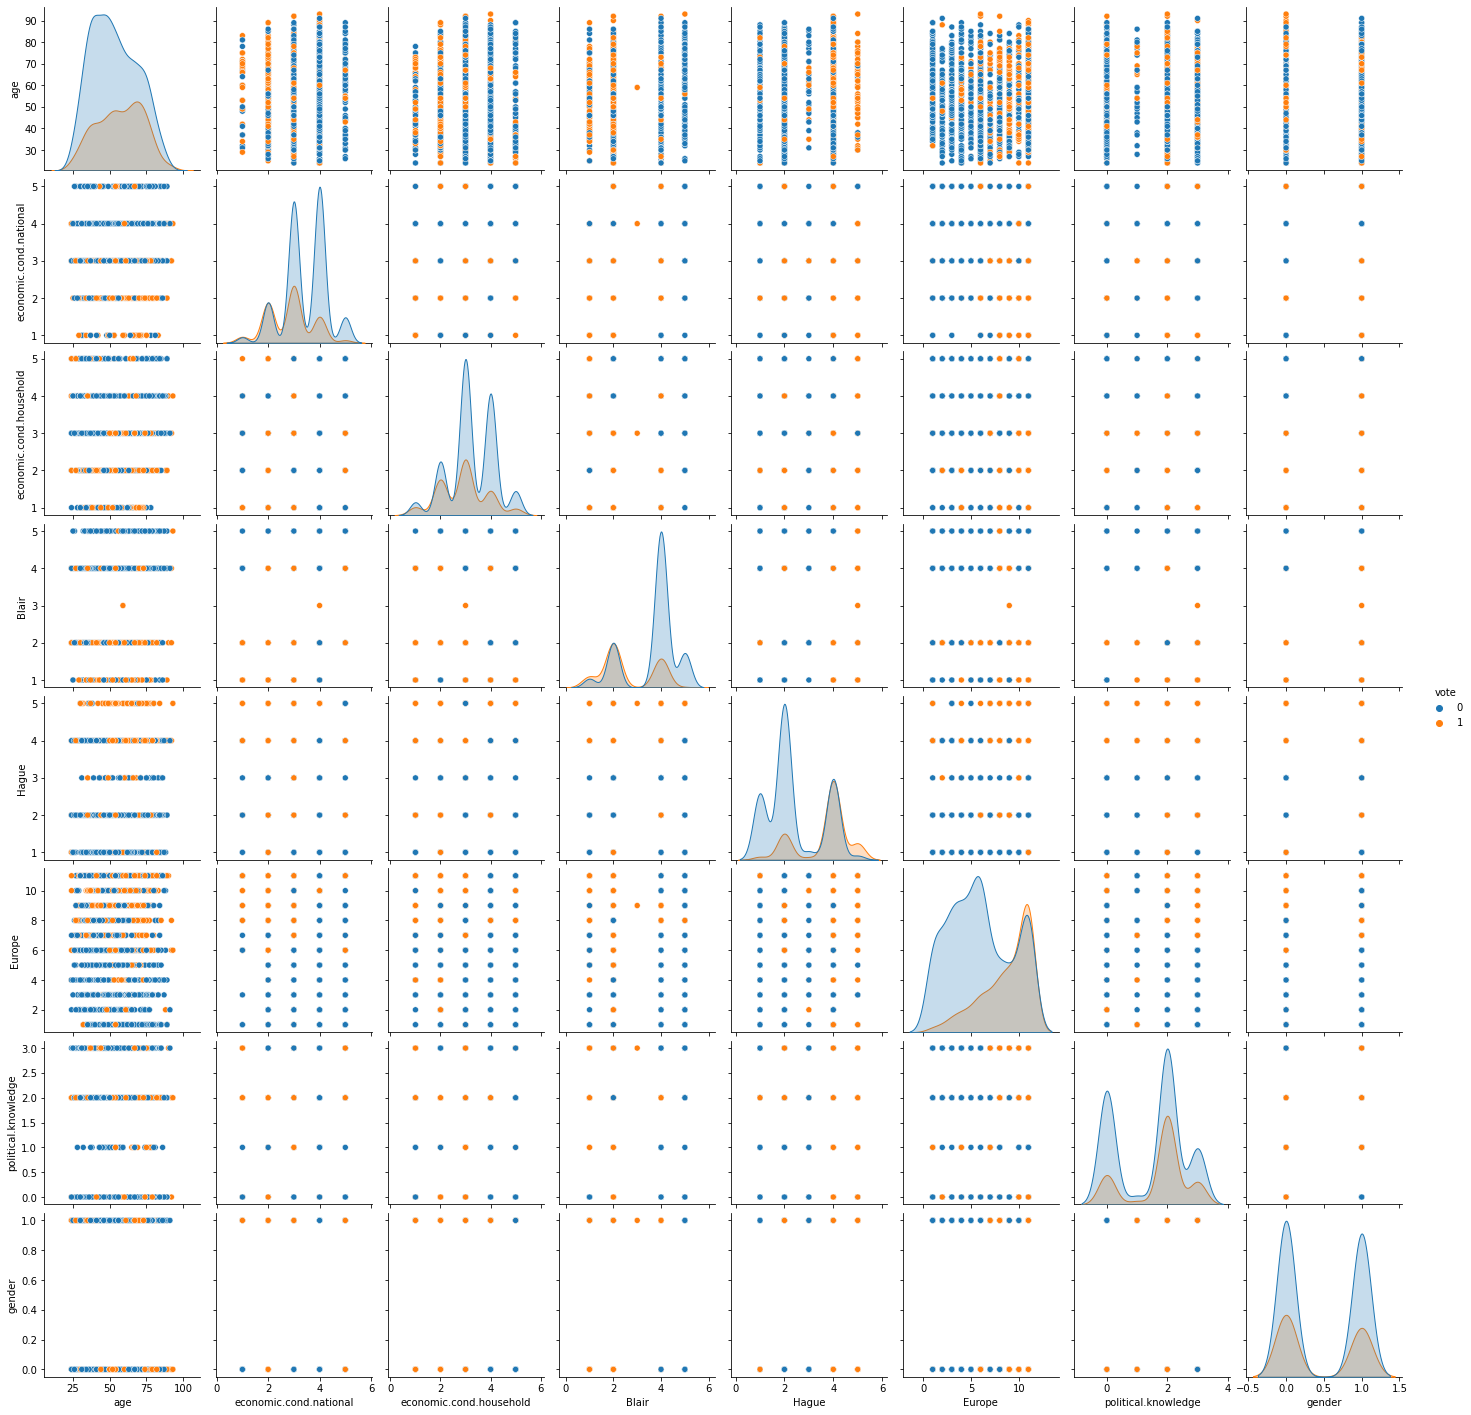

In [34]:
#checking the distribution of the data using vote variable
sns.pairplot(df, hue='vote')

In [35]:
covMatrix = np.cov(df,bias=True)
print (covMatrix)

[[168.69135802 135.48148148 133.34567901 ... 141.51851852 234.92592593
  289.54320988]
 [135.48148148 110.         107.40740741 ... 114.11111111 191.11111111
  235.14814815]
 [133.34567901 107.40740741 105.72839506 ... 112.03703704 185.40740741
  228.60493827]
 ...
 [141.51851852 114.11111111 112.03703704 ... 119.55555556 196.88888889
  242.96296296]
 [234.92592593 191.11111111 185.40740741 ... 196.88888889 338.
  414.59259259]
 [289.54320988 235.14814815 228.60493827 ... 242.96296296 414.59259259
  509.50617284]]


<AxesSubplot:>

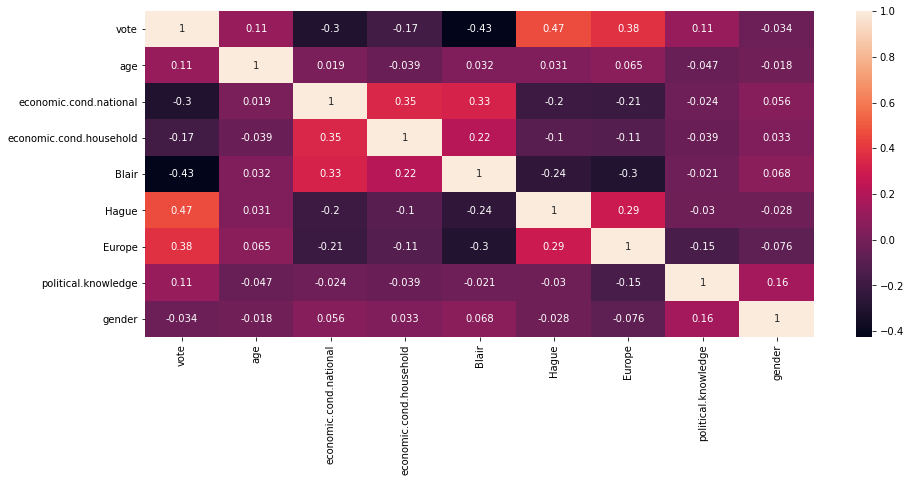

In [36]:
#checking the corelation among the variable by using heatmap
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),annot=True)

The variables seems to have low strong corelations between them.

economic.cond.household and economic.cond.national shows some corelation value which accounts to 0.35 thus showing positive corelation value.



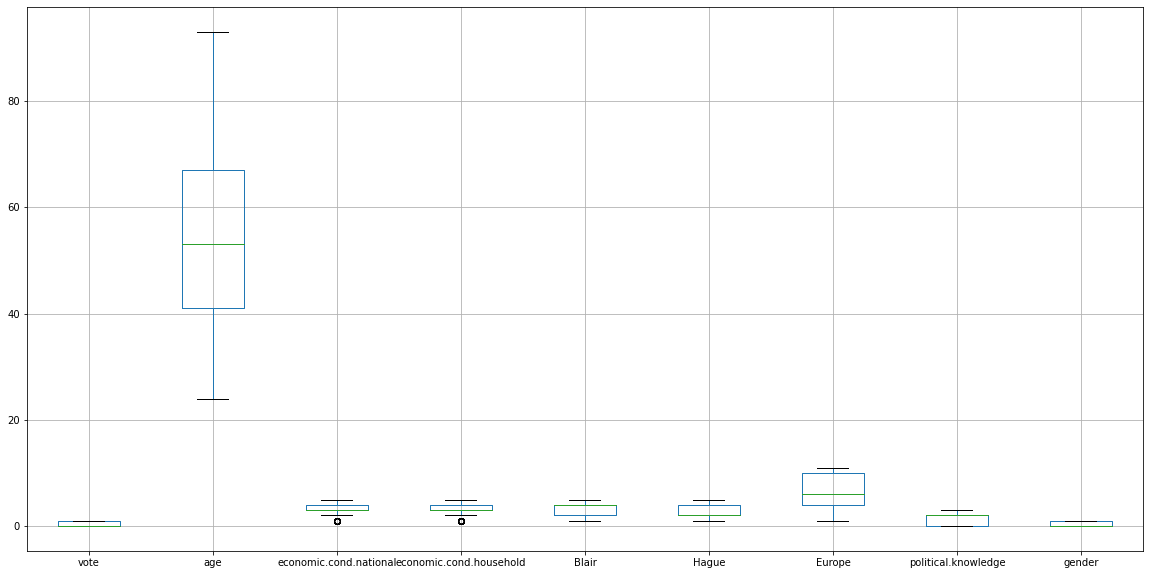

In [37]:
#checking for outliers values
plt.figure(figsize=(20,10))
df.boxplot()
plt.show()

Here it can be clearly seen that economic condtion national and economic condition household have some outliers values present in them.

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
df.head(3)

,vote,age,economic.cond.national,economic.cond.household,Blair,Hague,Europe,political.knowledge,gender
0,0,43,3,3,4,1,2,2,0
1,0,36,4,4,4,4,5,2,1
2,0,35,4,4,5,2,3,2,1


In [40]:
x = df.drop("vote",axis = 1)
y = df.pop("vote")

In [41]:
x_train,x_test , y_train, y_test = train_test_split(x,y,test_size = .30 ,random_state = 1)

In [42]:
lr = LogisticRegression(tol=0.0001,max_iter=2000,random_state= 0)
lr.fit(x_train,y_train)

LogisticRegression(max_iter=2000, random_state=0)

In [43]:
y_train_predict=lr.predict(x_train)

AxesSubplot(0.125,0.125;0.62x0.755)
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       754
           1       0.74      0.64      0.69       307

    accuracy                           0.83      1061
   macro avg       0.80      0.77      0.79      1061
weighted avg       0.83      0.83      0.83      1061



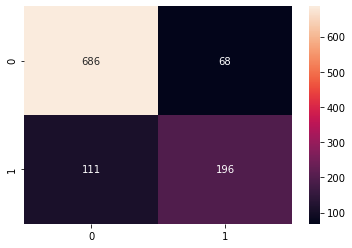

In [44]:
print(sns.heatmap(confusion_matrix(y_train,y_train_predict),annot=True , fmt="2g"))
y_train_predict=lr.predict(x_train)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_train ,y_train_predict))

In [45]:
print(confusion_matrix(y_test,lr.predict(x_test)))
print(classification_report(y_test,lr.predict(x_test)))

[[268  35]
 [ 40 113]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       303
           1       0.76      0.74      0.75       153

    accuracy                           0.84       456
   macro avg       0.82      0.81      0.81       456
weighted avg       0.83      0.84      0.83       456



In [46]:
from sklearn.metrics import mean_squared_error
print(mean_squared_error(y_train_predict, y_train))

0.16870876531573986


In [47]:
print(mean_squared_error(lr.predict(x_test), y_test))

0.16447368421052633


AUC: 0.890


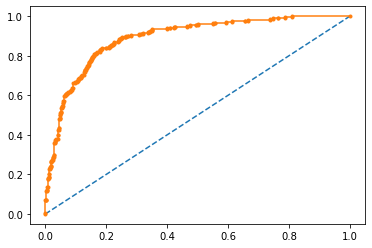

In [48]:
# AUC and ROC for the training data

# predict probabilities
probs = lr.predict_proba(x_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

AUC: 0.883


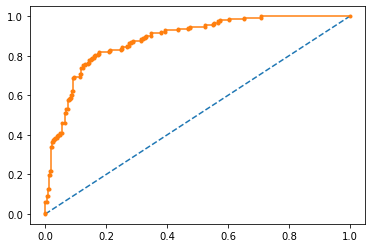

In [49]:
 #AUC and ROC for the test data

# predict probabilities
probs = lr.predict_proba(x_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [50]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn = knn.fit(x_train,y_train)
pred_label= knn.predict(x_test)
knn.score(x_test,y_test)

0.8157894736842105

In [51]:
print(confusion_matrix(knn.predict(x_train),y_train))

[[701 103]
 [ 53 204]]


In [52]:
print(classification_report(knn.predict(x_test),y_test))

              precision    recall  f1-score   support

           0       0.90      0.83      0.87       327
           1       0.65      0.77      0.70       129

    accuracy                           0.82       456
   macro avg       0.77      0.80      0.78       456
weighted avg       0.83      0.82      0.82       456



AUC: 0.923


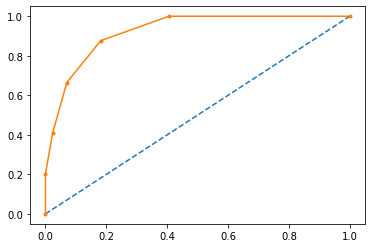

In [53]:
# AUC and ROC for the training data

# predict probabilities
probs = knn.predict_proba(x_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot

AUC: 0.852


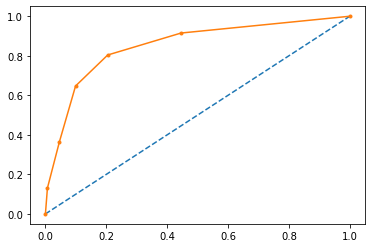

In [54]:
# predict probabilities
probs = knn.predict_proba(x_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier

In [56]:
param_grid = {
    'n_estimators' : [100,500,1000],
    'learning_rate' : [0.1,0.01,0.001],
    'algorithm' : ['SAMME', 'SAMME.R']
}

In [57]:
ADB_model=AdaBoostClassifier()

In [58]:
grid_search=GridSearchCV(estimator=ADB_model,param_grid=param_grid)

In [59]:
grid_search.fit(x_train,y_train)

GridSearchCV(estimator=AdaBoostClassifier(),
             param_grid={'algorithm': ['SAMME', 'SAMME.R'],
                         'learning_rate': [0.1, 0.01, 0.001],
                         'n_estimators': [100, 500, 1000]})

In [60]:
ADB_model=grid_search.best_estimator_

In [61]:
ADB_model.fit(x_train,y_train)

AdaBoostClassifier(learning_rate=0.01, n_estimators=1000)

In [62]:
## Performance Matrix on train data set
y_train_predict = ADB_model.predict(x_train)
model_score = ADB_model.score(x_train, y_train)
print(model_score)
print(confusion_matrix(y_train, y_train_predict))
print(classification_report(y_train, y_train_predict))

0.8369462770970783
[[702  52]
 [121 186]]
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       754
           1       0.78      0.61      0.68       307

    accuracy                           0.84      1061
   macro avg       0.82      0.77      0.79      1061
weighted avg       0.83      0.84      0.83      1061



AUC: 0.902


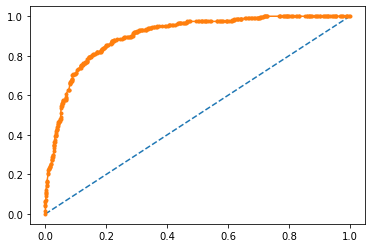

In [63]:
# AUC and ROC for the training data

# predict probabilities
probs = ADB_model.predict_proba(x_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')

In [64]:
## Performance Matrix on test data set
y_test_predict = ADB_model.predict(x_test)
model_score = ADB_model.score(x_test, y_test)
print(model_score)
print( confusion_matrix(y_test, y_test_predict))
print( classification_report(y_test, y_test_predict))

0.8092105263157895
[[271  32]
 [ 55  98]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       303
           1       0.75      0.64      0.69       153

    accuracy                           0.81       456
   macro avg       0.79      0.77      0.78       456
weighted avg       0.81      0.81      0.80       456



AUC: 0.884


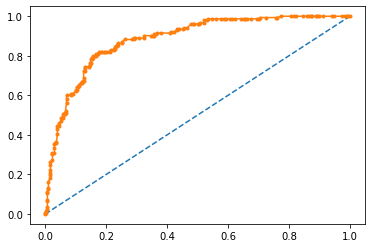

In [65]:
# predict probabilities
probs = ADB_model.predict_proba(x_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

In [66]:
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'min_samples_split' : [30,50,70,100],
    'min_samples_leaf':[15,25,35,50],
    'max_depth':[5,10,15,20],
    'random_state' : [0]
}

In [67]:
RF_model=RandomForestClassifier()

In [68]:
grid_search=GridSearchCV(estimator=RF_model,param_grid=param_grid,cv=10)

In [69]:
grid_search.fit(x_train,y_train)

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [15, 25, 35, 50],
                         'min_samples_split': [30, 50, 70, 100],
                         'random_state': [0]})

In [70]:
grid_search.best_estimator_

RandomForestClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=30,
                       random_state=0)

In [71]:
RF_model=grid_search.best_estimator_

In [72]:
RF_model.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=15, min_samples_split=30,
                       random_state=0)

In [73]:
## Performance Matrix on train data set
y_train_predict = RF_model.predict(x_train)
model_score =RF_model.score(x_train, y_train)
print(model_score)
print( confusion_matrix(y_train, y_train_predict))
print( classification_report(y_train, y_train_predict))

0.8576814326107446
[[708  46]
 [105 202]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       754
           1       0.81      0.66      0.73       307

    accuracy                           0.86      1061
   macro avg       0.84      0.80      0.82      1061
weighted avg       0.85      0.86      0.85      1061



AUC: 0.918


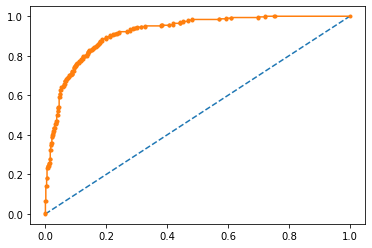

In [74]:
# AUC and ROC for the training data

# predict probabilities
probs = RF_model.predict_proba(x_train)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_train, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')

In [75]:
## Performance Matrix on test data set
y_test_predict = RF_model.predict(x_test)
model_score = RF_model.score(x_test, y_test)
print(model_score)
print( confusion_matrix(y_test, y_test_predict))
print( classification_report(y_test, y_test_predict))

0.8179824561403509
[[280  23]
 [ 60  93]]
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       303
           1       0.80      0.61      0.69       153

    accuracy                           0.82       456
   macro avg       0.81      0.77      0.78       456
weighted avg       0.82      0.82      0.81       456



AUC: 0.891


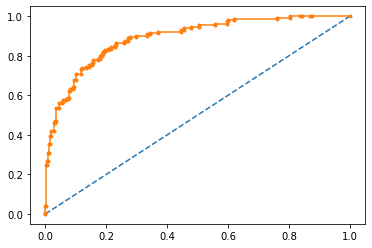

In [76]:
# AUC and ROC for the test data
# predict probabilities
probs = RF_model.predict_proba(x_test)
# keep probabilities for the positive outcome only
probs = probs[:, 1]
# calculate AUC
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, probs)
print('AUC: %.3f' % auc)
# calculate roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
plt.plot([0, 1], [0, 1], linestyle='--')
# plot the roc curve for the model
plt.plot(fpr, tpr, marker='.')
# show the plot
plt.show()

# Inferences:

The performance of the labour party is better than conservative party.

The number of voter who are high in number is female as compared to male voter.

By looking at confusion matrix overall it can be seen that actual and the predicted data are close to each other.

Thus showing that it is a right fit model.

By doing model tunning on random forest classifier  we got the better result.

But when we did bagging on random forest it gave better result on both test and train set thus giving good accuracy.

We will consider this model as our prime focus in this data set.

The overall accuracy seems to be same on both the cases i.e. train and test case.
